In [2]:
from dotenv import load_dotenv
import os

load_dotenv('../config/.env')

print(os.getenv("DB_USER"))
print(os.getenv("DB_PORT"))

tfg_user
5432


In [4]:
pip install psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 36.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
# Celda 1: Imports y conexion
import sys; sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
from db.db_utils import get_engine
engine = get_engine()
print('Conexion OK')


Conexion OK


In [6]:
# Celda 2: Cargar daily_features completo
with engine.connect() as conn:
    df = pd.read_sql(text("SELECT * FROM daily_features WHERE asset='BTC' ORDER BY date ASC"), conn)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
print(f'Filas: {len(df)} | Desde: {df.index.min()} | Hasta: {df.index.max()}')
df.info()


Filas: 2953 | Desde: 2018-02-01 00:00:00 | Hasta: 2026-03-06 00:00:00
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2953 entries, 2018-02-01 to 2026-03-06
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   asset            2953 non-null   object             
 1   close            2622 non-null   float64            
 2   returns          2621 non-null   float64            
 3   label            2622 non-null   float64            
 4   rsi_14           2608 non-null   float64            
 5   macd             2622 non-null   float64            
 6   macd_signal      2622 non-null   float64            
 7   bb_upper         2603 non-null   float64            
 8   bb_lower         2603 non-null   float64            
 9   sma_7            2616 non-null   float64            
 10  sma_30           2593 non-null   float64            
 11  sentiment_avg    18 non-null     float64      

In [7]:
# Celda 3: Valores nulos por columna
nulls = df.isnull().sum()
pct   = (nulls / len(df) * 100).round(1)
pd.DataFrame({'nulos': nulls, '%': pct})[nulls > 0]
# Esperado: sentiment_avg/std/count tendran nulos en dias sin textos. Es normal.


,nulos,%
close,331,11.2
returns,332,11.2
label,331,11.2
rsi_14,345,11.7
macd,331,11.2
macd_signal,331,11.2
bb_upper,350,11.9
bb_lower,350,11.9
sma_7,337,11.4
sma_30,360,12.2


In [8]:
# Celda 4: Distribucion de la variable objetivo (label)
print('Distribucion de la variable objetivo:')
print(df['label'].value_counts())
print(f'% dias alcistas: {df["label"].mean()*100:.1f}%')
# Esperado: ~52-55% de dias alcistas (Bitcoin suele ser ligeramente alcista en el largo plazo)


Distribucion de la variable objetivo:
label
1.0    1336
0.0    1286
Name: count, dtype: int64
% dias alcistas: 51.0%


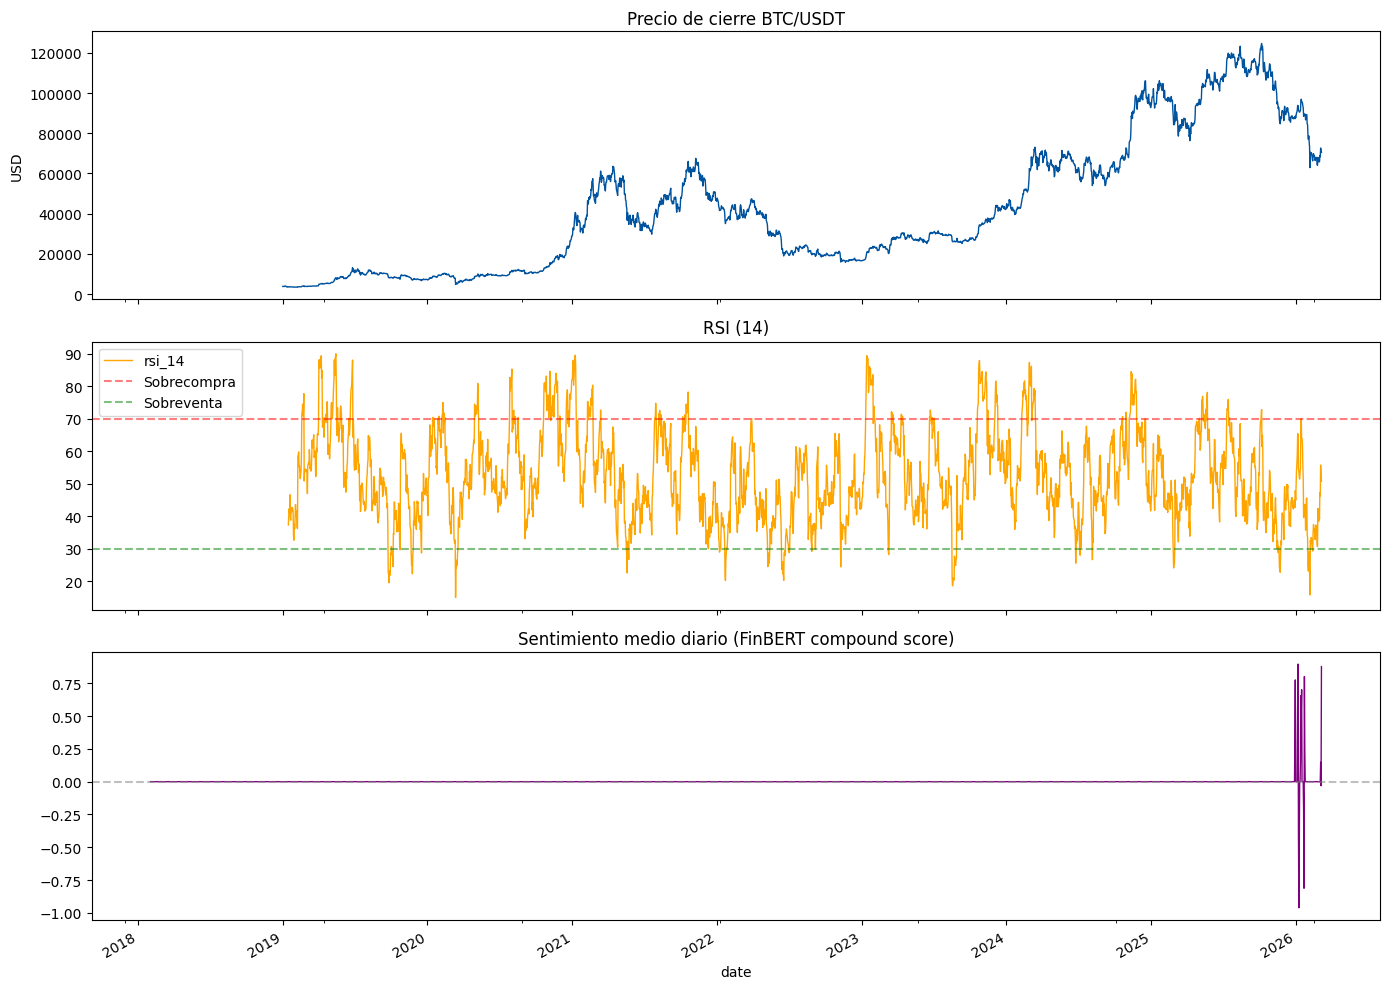

In [10]:
# Celda 5: Precio, RSI y sentiment historico
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
df['close'].plot(ax=axes[0], color='#00539F', linewidth=1)
axes[0].set_title('Precio de cierre BTC/USDT', fontsize=12)
axes[0].set_ylabel('USD')
df['rsi_14'].plot(ax=axes[1], color='orange', linewidth=1)
axes[1].axhline(70, color='red',   linestyle='--', alpha=0.5, label='Sobrecompra')
axes[1].axhline(30, color='green', linestyle='--', alpha=0.5, label='Sobreventa')
axes[1].set_title('RSI (14)', fontsize=12); axes[1].legend()
df['sentiment_avg'].fillna(0).plot(ax=axes[2], color='purple', linewidth=1)
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Sentimiento medio diario (FinBERT compound score)', fontsize=12)
plt.tight_layout()
plt.savefig('eda_precio_rsi_sentiment.png', dpi=150)
plt.show()


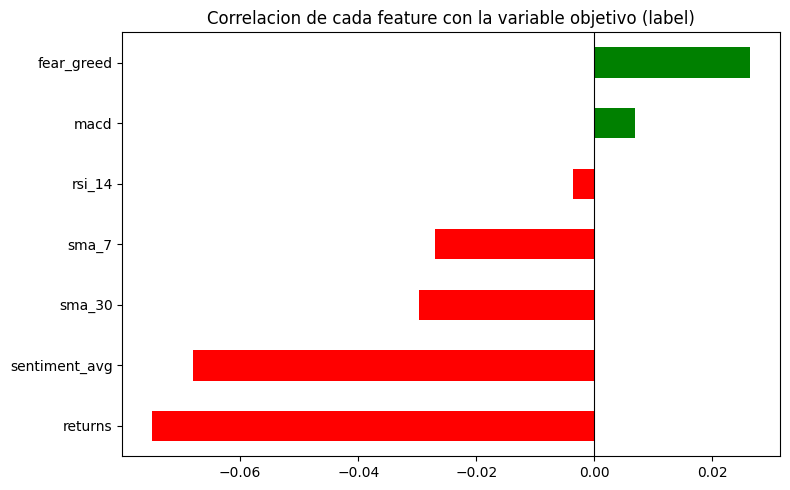

In [12]:
# Celda 6: Correlacion de features con la variable objetivo
features = ['rsi_14','macd','sma_7','sma_30','sentiment_avg','fear_greed','returns']
corr = df[features + ['label']].corr()['label'].drop('label').sort_values()
plt.figure(figsize=(8, 5))
corr.plot(kind='barh', color=['red' if x < 0 else 'green' for x in corr])
plt.title('Correlacion de cada feature con la variable objetivo (label)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('eda_correlaciones.png', dpi=150)
plt.show()
# Este grafico muestra que features tienen mayor relacion con la direccion del precio.
# Es directamente citable en la memoria del TFG.
